# ⁠Predicting House Prices Using Regression and Statistical Learning Methods

Made by:
- Nisa Ekmekcioglu


##  ⁠Project Description
In this project, I analyze the House Prices: Advanced Regression Techniques dataset from Kaggle, which contains detailed information about residential properties in Ames, Iowa, USA.

The dataset includes structural, geographical, and qualitative characteristics of houses, such as living area, number of rooms, construction year, overall quality, and neighborhood.

The main objective of this project is to predict house sale prices using various statistical and machine learning methods. I apply and compare multiple regression approaches, including:

- Multiple Linear Regression
- Ridge and Lasso Regression
- Regression Trees
- Random Forest and Boosting

The project aims to:

- Identify the most important factors affecting house prices
- Build predictive models
- Compare model performance using appropriate evaluation metrics
- Analyze uncertainty and interpret the results

## Data Description

The dataset contains 1460 observations and 81 variables. Below are some of the most important variables used in the analysis: ⁠ 
- `SalePrice` ⁠ – The final selling price of the house (target variable).
- `OverallQual` ⁠ – Overall material and finish quality of the house, rated from 1 (very poor) to 10 (excellent).
- `GrLivArea` ⁠ – Above-ground living area in square feet.
- `YearBuilt` ⁠ – Year in which the house was originally constructed.
- `⁠TotalBsmtSF⁠` – Total square footage of the basement.
- `⁠GarageCars⁠` – Number of cars that can fit in the garage.
- `⁠GarageArea` – Size of the garage in square feet.
- `FullBath⁠` – Number of full bathrooms in the house.
- `⁠TotRmsAbvGrd⁠` – Total number of rooms above ground, excluding bathrooms.
- `⁠Neighborhood⁠` – Physical location of the property within the city.
- `KitchenQual⁠` – Quality of the kitchen (Excellent, Good, Typical, Fair, Poor).
- `⁠Fireplaces⁠` – Number of fireplaces in the house.
- `⁠LotArea⁠` – Size of the property lot in square feet.
- `⁠MSSubClass⁠` – Type of dwelling involved in the sale (e.g., single-family, duplex).

## ⁠Dataset Justification

The House Prices dataset was chosen for this project for several reasons:

- First, the dataset is publicly available and well-documented. This ensures transparency and reproducibility of the analysis.

- Second, the dataset contains a large number of explanatory variables from different domains, including structural, qualitative, and geographical features. This makes it suitable for applying various regression and regularization techniques.                                   

- Third, house price prediction is a relevant real-world problem in economics, finance, and urban planning. Understanding price determinants is valuable for buyers, sellers, investors, and policymakers.

- Finally, the dataset includes both numerical and categorical variables as well as missing values, which allows us to demonstrate data preprocessing, EDA, and uncertainty analysis techniques learned in the course.


In [ ]:
#Importing all the necessary variables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import pearsonr


sns.set_theme(style="whitegrid", palette="pastel")
pd.set_option("display.max_columns", 120)

In [ ]:
# Load the dataset
df = pd.read_csv("Data/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Making the column names look better with the snake case
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'(.)([A-Z][a-z]+)', r'\1_\2', regex=True)
      .str.replace(r'([a-z0-9])([A-Z])', r'\1_\2', regex=True)
      .str.replace(r'[^0-9a-zA-Z_]+', '_', regex=True)
      .str.lower()
      .str.strip('_')
)

df.head()

,id,ms_sub_class,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,land_slope,neighborhood,condition1,condition2,bldg_type,house_style,overall_qual,overall_cond,year_built,year_remod_add,roof_style,roof_matl,exterior1st,exterior2nd,mas_vnr_type,mas_vnr_area,exter_qual,exter_cond,foundation,bsmt_qual,bsmt_cond,bsmt_exposure,bsmt_fin_type1,bsmt_fin_sf1,bsmt_fin_type2,bsmt_fin_sf2,bsmt_unf_sf,total_bsmt_sf,heating,heating_qc,central_air,electrical,1st_flr_sf,2nd_flr_sf,low_qual_fin_sf,gr_liv_area,bsmt_full_bath,bsmt_half_bath,full_bath,half_bath,bedroom_abv_gr,kitchen_abv_gr,kitchen_qual,tot_rms_abv_grd,functional,fireplaces,fireplace_qu,garage_type,garage_yr_blt,garage_finish,garage_cars,garage_area,garage_qual,garage_cond,paved_drive,wood_deck_sf,open_porch_sf,enclosed_porch,3_ssn_porch,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,sale_price
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Checking the description of the numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
ms_sub_class,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
lot_frontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
lot_area,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
overall_qual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
overall_cond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
year_built,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
year_remod_add,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
mas_vnr_area,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
bsmt_fin_sf1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
# Getting the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1460 non-null   int64  
 1   ms_sub_class     1460 non-null   int64  
 2   ms_zoning        1460 non-null   object 
 3   lot_frontage     1201 non-null   float64
 4   lot_area         1460 non-null   int64  
 5   street           1460 non-null   object 
 6   alley            91 non-null     object 
 7   lot_shape        1460 non-null   object 
 8   land_contour     1460 non-null   object 
 9   utilities        1460 non-null   object 
 10  lot_config       1460 non-null   object 
 11  land_slope       1460 non-null   object 
 12  neighborhood     1460 non-null   object 
 13  condition1       1460 non-null   object 
 14  condition2       1460 non-null   object 
 15  bldg_type        1460 non-null   object 
 16  house_style      1460 non-null   object 
 17  overall_qual  

In [ ]:
# Checking the missing values
df.isna().sum().sort_values(ascending=False).head(20)

pool_qc           1453
misc_feature      1406
alley             1369
fence             1179
fireplace_qu       690
lot_frontage       259
garage_yr_blt       81
garage_cond         81
garage_type         81
garage_finish       81
garage_qual         81
bsmt_fin_type2      38
bsmt_exposure       38
bsmt_qual           37
bsmt_cond           37
bsmt_fin_type1      37
mas_vnr_area         8
mas_vnr_type         8
electrical           1
id                   0
dtype: int64

In [ ]:
# Checking the duplicates
print('Number of duplicates:', df.duplicated().sum())

Number of duplicates: 0


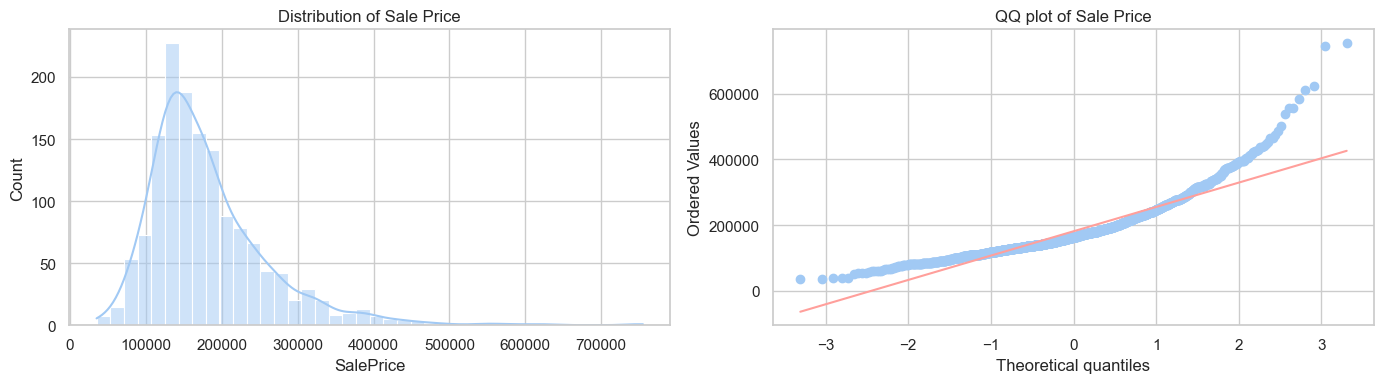

In [ ]:
# Exploratory plots: visualizing the distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(
    data=df,
    x="sale_price",
    bins=40,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Sale Price")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Count")

stats.probplot(df["sale_price"], dist="norm", plot=axes[1])
axes[1].set_title("QQ plot of Sale Price")
plt.tight_layout()
plt.show()

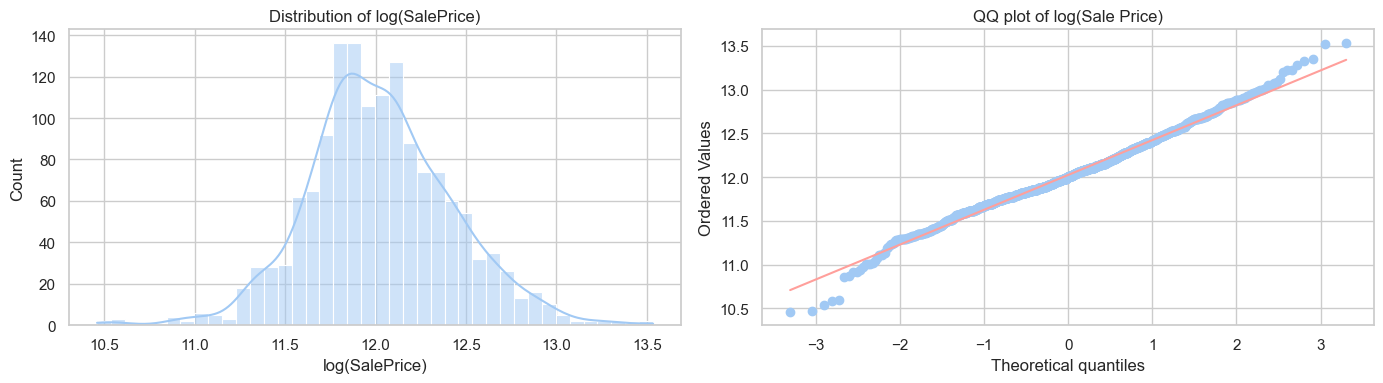

In [ ]:
# Creating a log-transformed target to reduce skewness and improve model
df["log_sale_price"] = np.log(df["sale_price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(
    data=df,
    x="log_sale_price",
    bins=40,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of log(SalePrice)")
axes[0].set_xlabel("log(SalePrice)")
axes[0].set_ylabel("Count")

stats.probplot(df["log_sale_price"], dist="norm", plot=axes[1])
axes[1].set_title("QQ plot of log(Sale Price)")
plt.tight_layout()
plt.show()

In [ ]:
# Let's add some variables
df['total_bathrooms'] = df['bsmt_full_bath'] + df['bsmt_half_bath']/2 + df['full_bath'] + df['half_bath']/2
df['remodeled'] = df['year_built'] != df['year_remod_add']
df['age'] = df['yr_sold'] - df['year_built']
df['new'] = df['yr_sold'] == df['year_built']
df['total_sq_feet'] = df['gr_liv_area'] + df['total_bsmt_sf']
df['total_porch_sq_feet'] = df['open_porch_sf'] + df['enclosed_porch'] + df['screen_porch'] + df['3_ssn_porch']

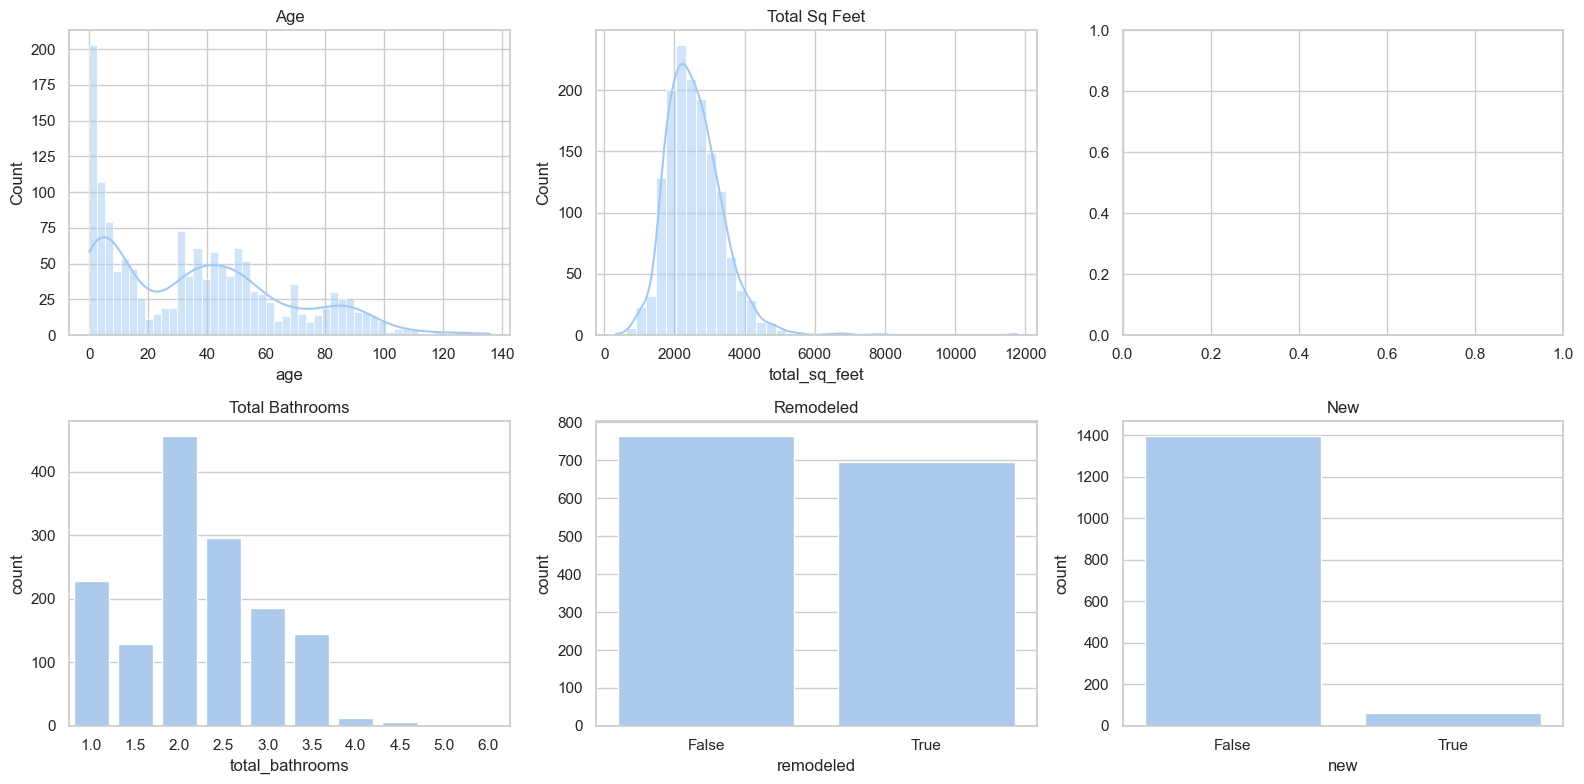

In [ ]:
# Visualizing relationships of key predictors 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(df["age"], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age")

sns.histplot(df["total_sq_feet"], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Total Sq Feet")

sns.countplot(data=df, x="total_bathrooms", ax=axes[1, 0])
axes[1, 0].set_title("Total Bathrooms")

sns.countplot(data=df, x="remodeled", ax=axes[1, 1])
axes[1, 1].set_title("Remodeled")

sns.countplot(data=df, x="new", ax=axes[1, 2])
axes[1, 2].set_title("New")

plt.tight_layout()
plt.show()


## Section summary: Data preprocessing
- I checked the data. The dataset looks good, there are some missing values, but in the columns, that are not very important. I will not delete the rows, so I dont lose the important information the other columns contain and if I need them, I will deal with them in the later steps.
- I also did some data preprocessing: changed the column names, so it's more convinient and added some transformed variables for the later analysis.
- I also created a log-transformed target `log_sale_price` = log(SalePrice) to reduce right-skewness and make the relationship with predictors closer to linear.
- Produced initial visualizations (histograms/scatterplots) for several key variables to understand how basic house characteristics relate to price.

**Takeaway**: House prices are strongly right-skewed; the log transformation gives a more stable scale for modeling and evaluation.

***

# EDA

In [ ]:
# Preparing the fucntions, that we will use later in the model-building
# We put all the fucntions here in the beginning, to clean the code below

# To return the RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Correlations, for the matrix plot of correlatins
def corrfunc(x, y, **kws):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    r, p = pearsonr(x, y)
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = ""

    ax = plt.gca()
    ax.annotate(
        f"corr\n{r:.2f}{stars}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )
    ax.set_axis_off()

# Function for the Forward Step Selection
def forward_selection_aic(X, y):
    remaining = list(X.columns)
    selected = []
    current_aic = np.inf
    best_model = None

    while remaining:
        aic_with_candidates = []
        for candidate in remaining:
            X_candidate = sm.add_constant(X[selected + [candidate]])
            model = sm.OLS(y, X_candidate).fit()
            aic_with_candidates.append((model.aic, candidate, model))

        aic_with_candidates.sort(key=lambda x: x[0])
        best_aic, best_candidate, best_candidate_model = aic_with_candidates[0]

        if best_aic < current_aic - 1e-6:  # small tolerance
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_aic = best_aic
            best_model = best_candidate_model
        else:
            break

    return selected, best_model


***

## Linear Regression

In [ ]:
# Our target variable
y = df["log_sale_price"]

# X, but only numeric predictors
X = df.select_dtypes(include=[np.number])

In [ ]:
for col in ["id", "sale_price", "log_sale_price"]:
    if col in X.columns:
        X = X.drop(columns=col)

In [ ]:
X.isna().sum().sort_values(ascending=False).head()

lot_frontage       259
garage_yr_blt       81
mas_vnr_area         8
3_ssn_porch          0
tot_rms_abv_grd      0
dtype: int64

In [ ]:
# We are filling the missing data with the median
X = X.fillna(X.median(numeric_only=True))

In [ ]:
X.isna().sum().sort_values(ascending=False).head()

ms_sub_class       0
lot_frontage       0
tot_rms_abv_grd    0
fireplaces         0
garage_yr_blt      0
dtype: int64

In [ ]:
# Creating our test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
lin_reg_pred = lin_reg.predict(X_test)

In [ ]:
rmse_ols = rmse(y_test, lin_reg_pred)
r2_ols = r2_score(y_test, lin_reg_pred)

print("Baseline Multiple Linear Regression")
print(f"Test RMSE: {rmse_ols:.4f}")
print(f"Test R2: {r2_ols:.4f}")

Baseline Multiple Linear Regression
Test RMSE: 0.1230
Test R2: 0.8982


In [ ]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

In [ ]:
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())
print("\nAIC:", ols.aic)
print("BIC:", ols.bic)

                            OLS Regression Results                            
Dep. Variable:         log_sale_price   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     205.5
Date:                Sun, 08 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:46:32   Log-Likelihood:                 555.28
No. Observations:                1168   AIC:                            -1041.
Df Residuals:                    1133   BIC:                            -863.4
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  19.0677    

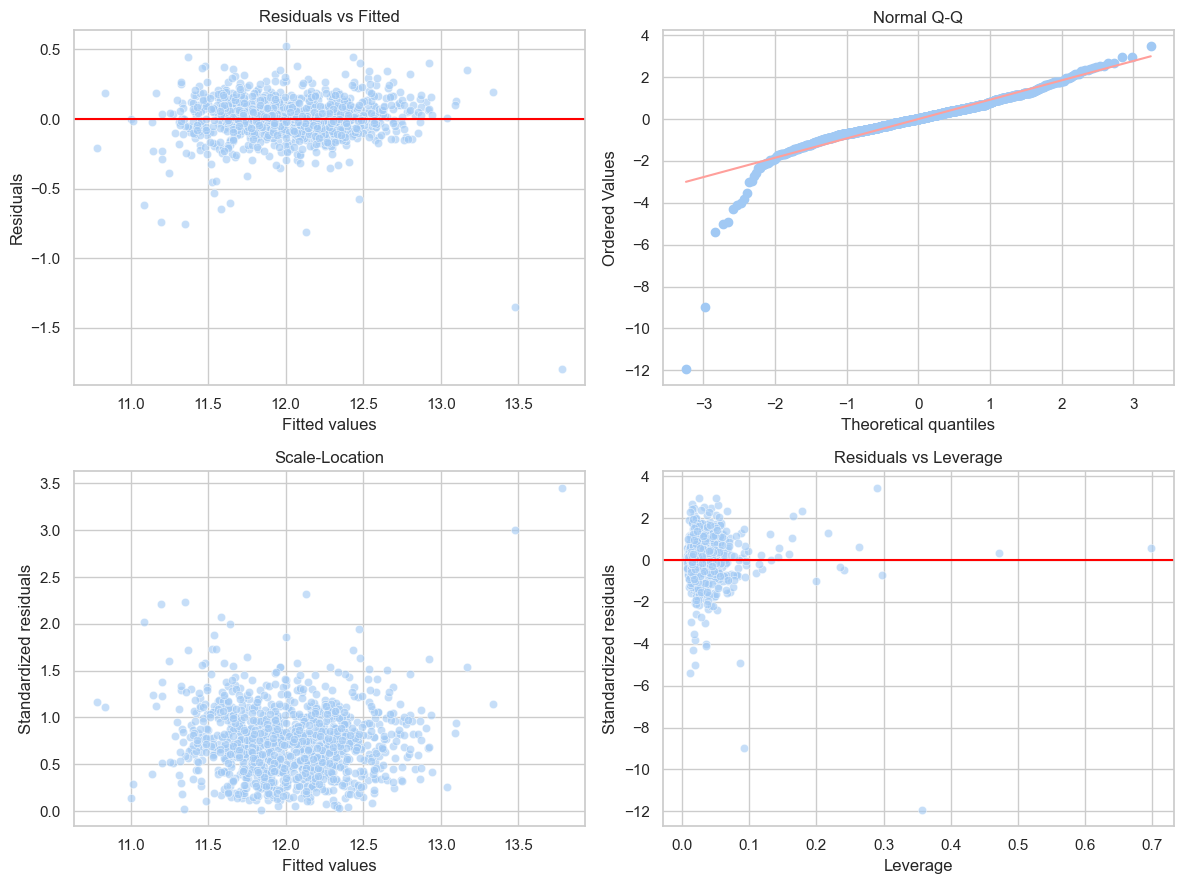

In [ ]:
# Diagnostics plots for OLS
fitted = ols.fittedvalues
resid = ols.resid
std_resid = resid / resid.std()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Residuals vs Fitted
sns.scatterplot(x=fitted, y=resid, ax=axes[0, 0], alpha=0.6)
axes[0, 0].axhline(0, color="red")
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# Normal Q-Q
stats.probplot(std_resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q")

# Scale-Location
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(std_resid)), ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("Standardized residuals")

# Residuals vs Leverage
influence = ols.get_influence()
leverage = influence.hat_matrix_diag
sns.scatterplot(x=leverage, y=std_resid, ax=axes[1, 1], alpha=0.6)
axes[1, 1].axhline(0, color="red")
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized residuals")

plt.tight_layout()
plt.show()

In [ ]:
top_cols = X_train.corrwith(y_train).abs().sort_values(ascending=False).head(5).index
plot_df = df[list(top_cols) + ["log_sale_price"]].dropna()

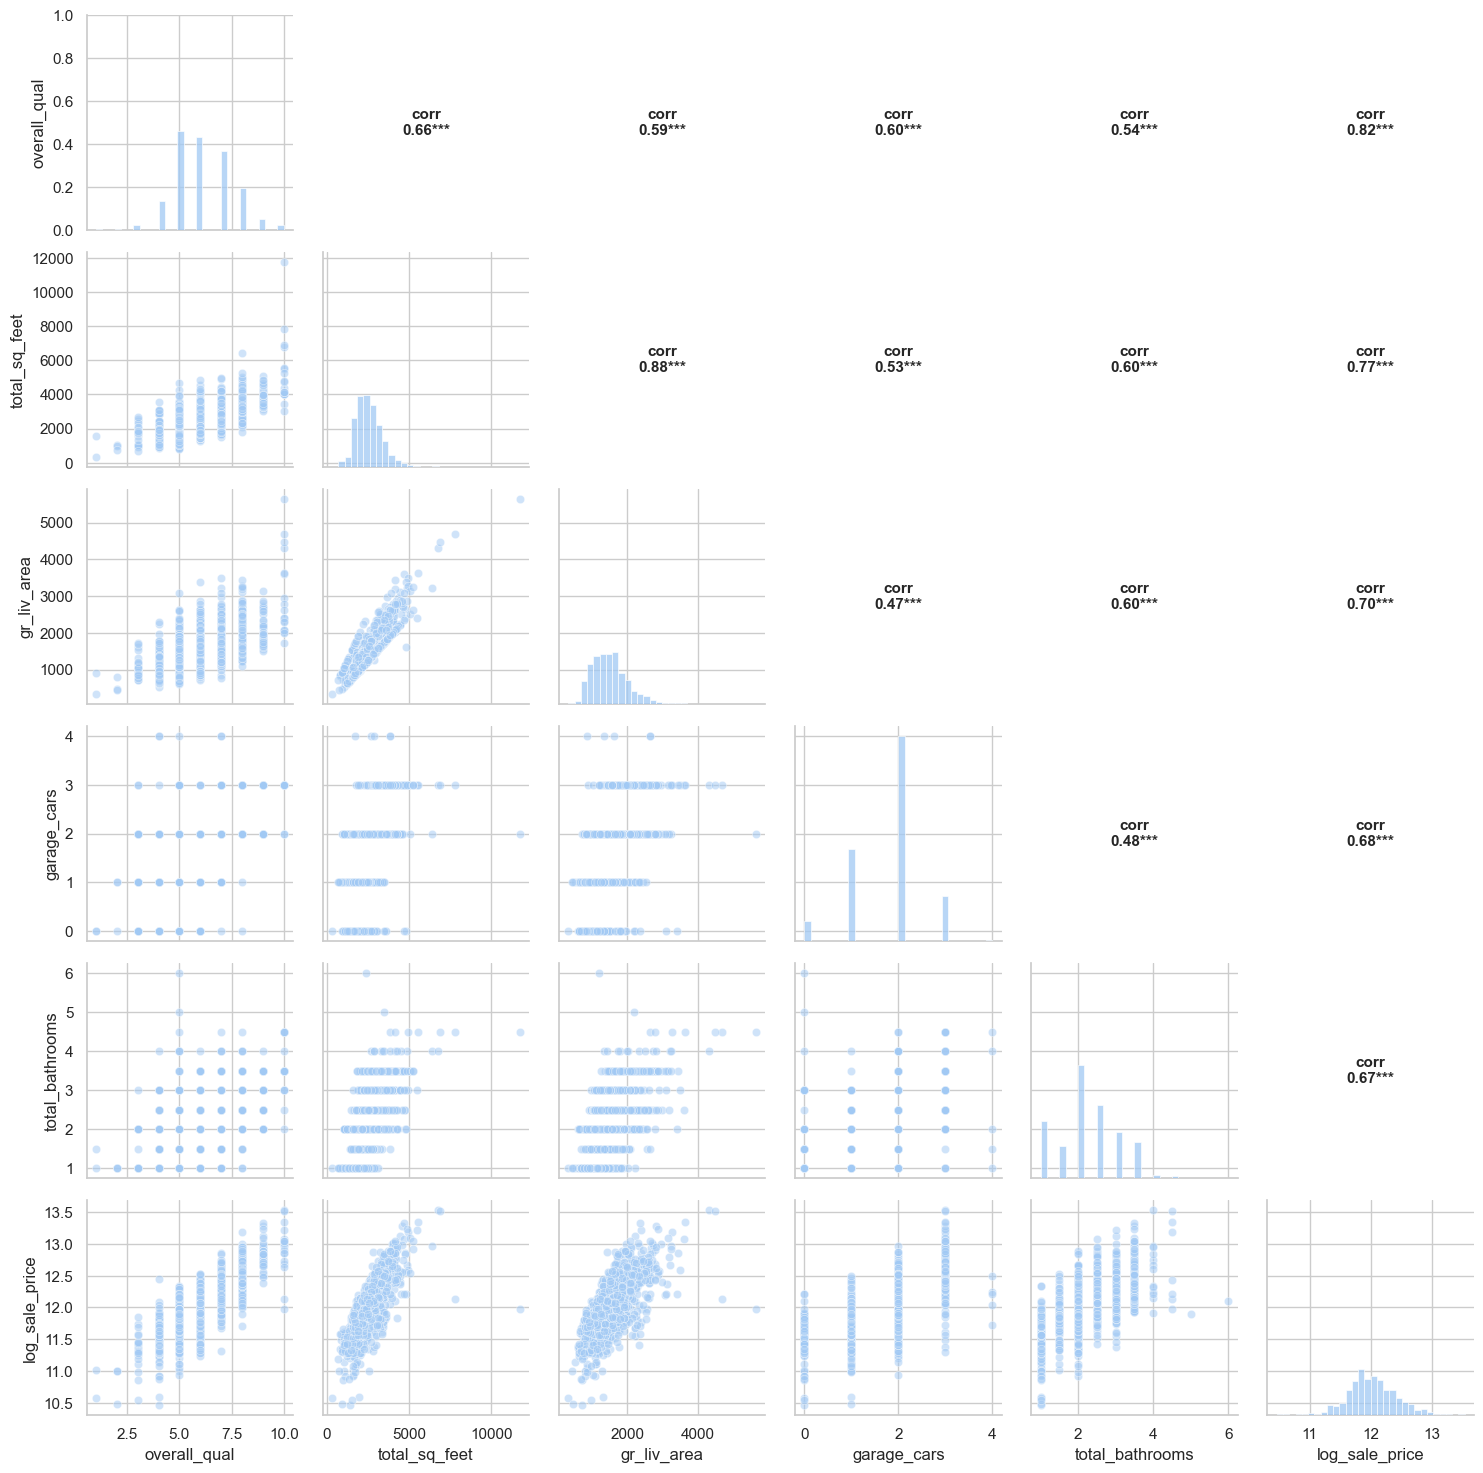

In [ ]:
# The correlation plots
g = sns.PairGrid(plot_df)

g.map_lower(sns.scatterplot, alpha=0.5)
g.map_diag(sns.histplot, bins=30)
g.map_upper(corrfunc)

plt.show()

## Section summary: 
- Computed correlations between numeric features and the target to identify the most informative predictors.
- Visualized the strongest relationships using correlation-based plots.

- Size/quality-related variables (e.g., overall quality, living area, basement/garage measures) typically show the strongest association with (log) sale price, motivating their inclusion in the models.

***

## Forward Step Selection

In [ ]:
selected_vars, step_model = forward_selection_aic(X_train, y_train)

print("Selected variables (AIC forward):", selected_vars)
print(step_model.summary())
print("\nAIC:", step_model.aic, "BIC:", step_model.bic)

Selected variables (AIC forward): ['overall_qual', 'total_sq_feet', 'garage_cars', 'total_bathrooms', 'overall_cond', 'age', 'fireplaces', 'ms_sub_class', 'gr_liv_area', 'wood_deck_sf', 'screen_porch', 'pool_area', 'lot_area', 'year_remod_add', 'bsmt_full_bath', 'tot_rms_abv_grd', 'kitchen_abv_gr', 'yr_sold', '1st_flr_sf']
                            OLS Regression Results                            
Dep. Variable:         log_sale_price   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     370.2
Date:                Sun, 08 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:46:53   Log-Likelihood:                 552.00
No. Observations:                1168   AIC:                            -1064.
Df Residuals:                    1148   BIC:                            -962.7
Df Model:                          19      

In [ ]:
# Baseline
pred_base = ols.predict(X_test_sm)
rmse_base = rmse(y_test, pred_base)
r2_base = r2_score(y_test, pred_base)

# Step model
X_test_step = sm.add_constant(X_test[selected_vars], has_constant="add")
pred_step = step_model.predict(X_test_step)
rmse_step = np.sqrt(mean_squared_error(y_test, pred_step))
r2_step = r2_score(y_test, pred_step)

results = pd.DataFrame({
    "model": ["Baseline OLS", "Forward AIC"],
    "AIC": [ols.aic, step_model.aic],
    "BIC": [ols.bic, step_model.bic],
    "RMSE_test": [rmse_base, rmse_step],
    "R2_test": [r2_base, r2_step]
})

results

,model,AIC,BIC,RMSE_test,R2_test
0,Baseline OLS,-1040.563745,-863.357059,0.122975,0.898165
1,Forward AIC,-1063.998938,-962.737974,0.123549,0.897213


In [ ]:
# still the target
y = df["log_sale_price"]

# X only selected_vars
X = df[selected_vars]

# deleting the NAs
model_df = pd.concat([y, X], axis=1).dropna()
y_m = model_df["log_sale_price"]
X_m = model_df[selected_vars]
X_m = sm.add_constant(X_m)

# improved model
improved_model = sm.OLS(y_m, X_m).fit()
print(improved_model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_sale_price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     494.4
Date:                Sun, 08 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:46:55   Log-Likelihood:                 741.78
No. Observations:                1460   AIC:                            -1444.
Df Residuals:                    1440   BIC:                            -1338.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              17.3603      5.865     

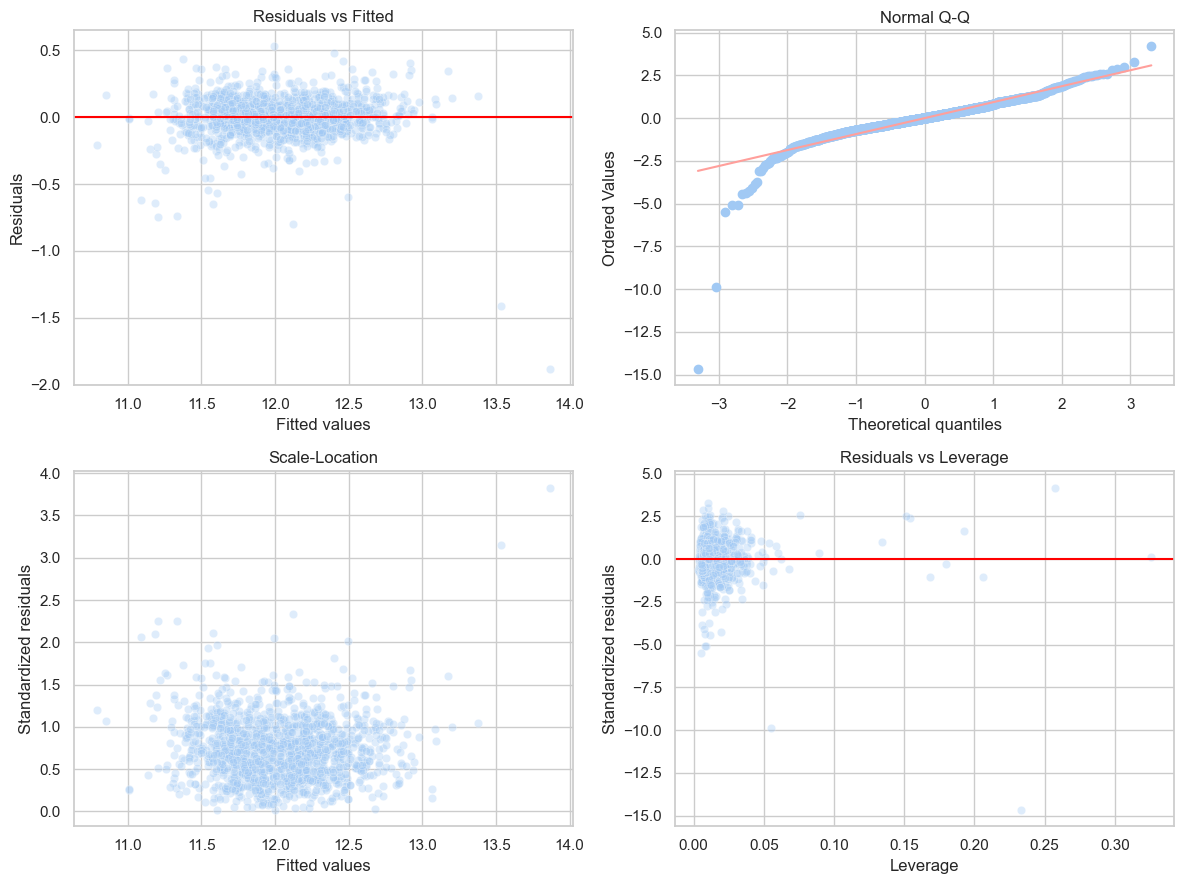

In [ ]:
# Diagnostics plots for improved model

fitted = improved_model.fittedvalues
resid = improved_model.resid

influence = improved_model.get_influence()
std_resid = influence.resid_studentized_internal   
leverage = influence.hat_matrix_diag             

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Residuals vs Fitted
sns.scatterplot(x=fitted, y=resid, ax=axes[0, 0], alpha=0.35)
axes[0, 0].axhline(0, color="red")
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# Normal Q-Q
stats.probplot(std_resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q")

# Scale-Location
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(std_resid)), ax=axes[1, 0], alpha=0.35)
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("Standardized residuals")

# Residuals vs Leverage
sns.scatterplot(x=leverage, y=std_resid, ax=axes[1, 1], alpha=0.35)
axes[1, 1].axhline(0, color="red")
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized residuals")

plt.tight_layout()
plt.show()


## Section summary: 
- Ran a baseline OLS model as a benchmark.
- Performed forward selection using AIC to build a more parsimonious linear model.
- Compared out-of-sample performance:


- Baseline OLS: RMSE = 0.1230, R² = 0.8982
- Forward AIC: RMSE = 0.1235, R² = 0.8972

Forward AIC produced a slightly simpler model, but predictive performance was very similar (and marginally worse) than the baseline OLS on the test split.

***

## Regression Tree

In [ ]:
# Regression tree
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train, y_train)

y_pred_train = tree_full.predict(X_train)
y_pred_test  = tree_full.predict(X_test)

print("Train RMSE:", rmse(y_train, y_pred_train))
print("Test RMSE:", rmse(y_test, y_pred_test))
print("Test R2:", r2_score(y_test, y_pred_test))

Train RMSE: 0.001183431195494332
Test RMSE: 0.1863349590794851
Test R2: 0.7661976559277364


In [ ]:
# Tune a regression tree over max_depth to control complexity and reduce overfitting
depths = range(2, 21)

results = []

for d in depths:
    tree = DecisionTreeRegressor(
        max_depth=d,
        random_state=42
    )
    tree.fit(X_train, y_train)

    y_pred = tree.predict(X_test)

    results.append({
    "max_depth": d,
    "RMSE_test": rmse(y_test, y_pred),
    "R2_test": r2_score(y_test, y_pred)
})

results_df = pd.DataFrame(results)
results_df

,max_depth,RMSE_test,R2_test
0,2,0.224049,0.661977
1,3,0.208065,0.708488
2,4,0.191337,0.753477
3,5,0.180156,0.781446
4,6,0.167376,0.811354
5,7,0.178164,0.786254
6,8,0.174856,0.794115
7,9,0.179034,0.784159
8,10,0.178098,0.786412
9,11,0.183699,0.772765


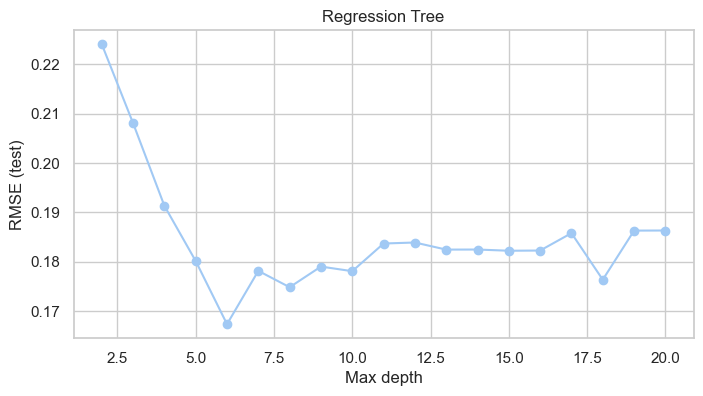

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["max_depth"], results_df["RMSE_test"], marker="o")
plt.xlabel("Max depth")
plt.ylabel("RMSE (test)")
plt.title("Regression Tree")
plt.show()

In [ ]:
best_depth = results_df.loc[
    results_df["RMSE_test"].idxmin(), "max_depth"
]

best_depth

6

In [ ]:
tree_final = DecisionTreeRegressor(
    max_depth=best_depth,
    random_state=42
)

tree_final.fit(X_train, y_train)

y_pred_test = tree_final.predict(X_test)

rmse_tree = rmse(y_test, y_pred_test)
r2_tree   = r2_score(y_test, y_pred_test)

print("Decision Tree Regression")
print(f"Tree RMSE: {rmse_tree:.4f}")
print(f"Tree R2: {r2_tree:.4f}")

Decision Tree Regression
Tree RMSE: 0.1674
Tree R2: 0.8114


Regression tree does not outperform the linear regression model in terms of predictive accuracy, but provides interpretability and captures non-linear relationships.

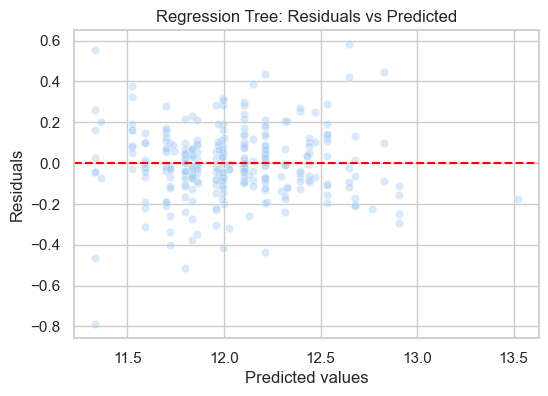

In [ ]:
residuals = y_test - y_pred_test

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Regression Tree: Residuals vs Predicted")
plt.show()


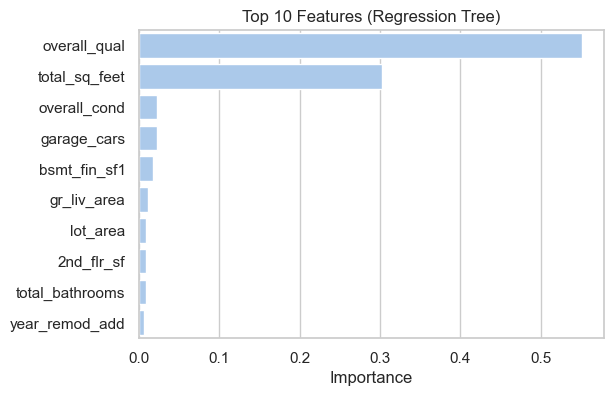

In [ ]:
importances = pd.Series(
    tree_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title("Top 10 Features (Regression Tree)")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

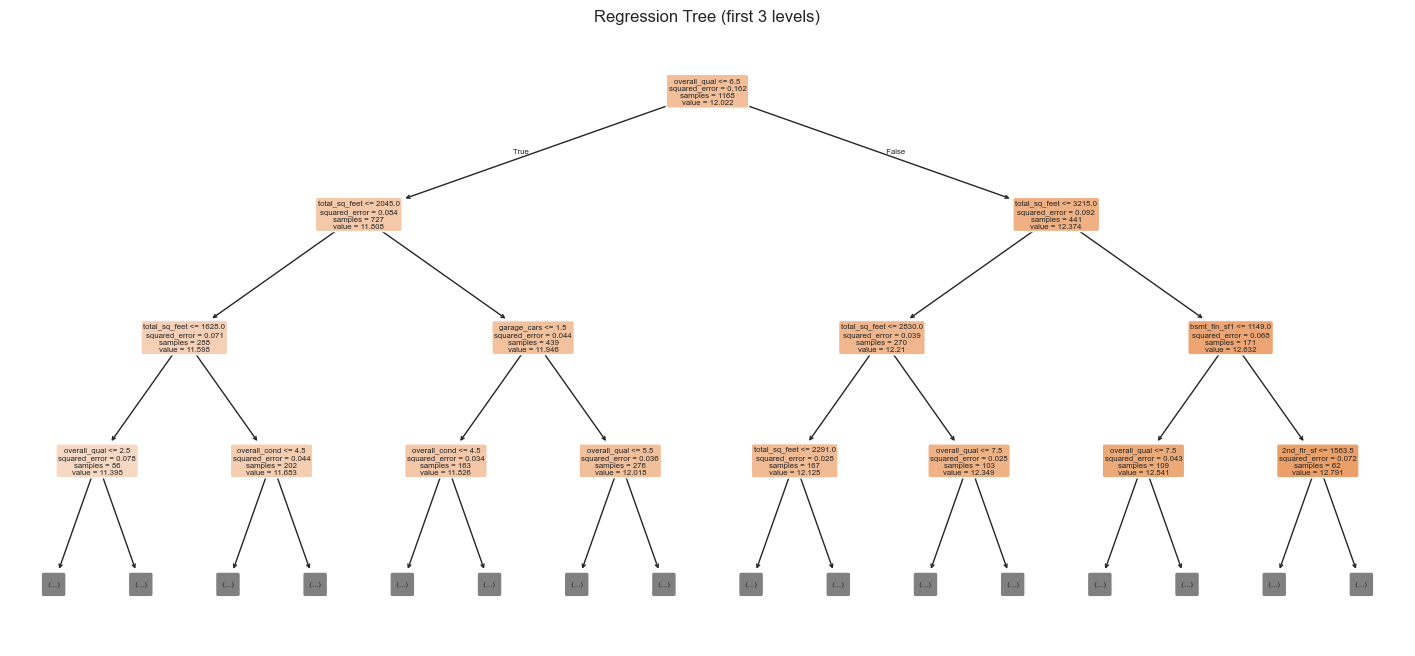

In [ ]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree_final,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Regression Tree (first 3 levels)")
plt.show()

In [ ]:
# Comparison table
comparison_ols_tree = pd.DataFrame({
    "Model": ["OLS", "Stepwise OLS", "Regression Tree"],
    "RMSE_test": [rmse_ols, rmse_step, rmse_tree],
    "R2_test": [r2_ols, r2_step, r2_tree]
})

comparison_ols_tree

,Model,RMSE_test,R2_test
0,OLS,0.122975,0.898165
1,Stepwise OLS,0.123549,0.897213
2,Regression Tree,0.167376,0.811354


Among the considered models, the stepwise linear regression achieved the best predictive performance.

***

## Ridge

In [ ]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns

In [ ]:
# Define preprocessing: median imputation for numeric and one-hot encoding for categorical variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

In [ ]:
alphas = np.logspace(-3, 3, 60) 

ridge = RidgeCV(alphas=alphas, cv=5)

model_ridge = Pipeline(steps=[
    ("preprocess", preprocess),
    ("ridge", ridge)
])

In [ ]:
model_ridge.fit(X_train, y_train)
y_pred = model_ridge.predict(X_test)

rmse_ridge = rmse(y_test, y_pred) 
r2_ridge = r2_score(y_test, y_pred)

best_alpha = model_ridge.named_steps["ridge"].alpha_

print("RIDGE:")
print(f"Best alpha: {best_alpha:.4f}")
print(f"Ridge RMSE: {rmse_ridge:.4f}")
print(f"Ridge R2: {r2_ridge:.4f}")

RIDGE:
Best alpha: 153.6175
Ridge RMSE: 0.1224
Ridge R2: 0.8992


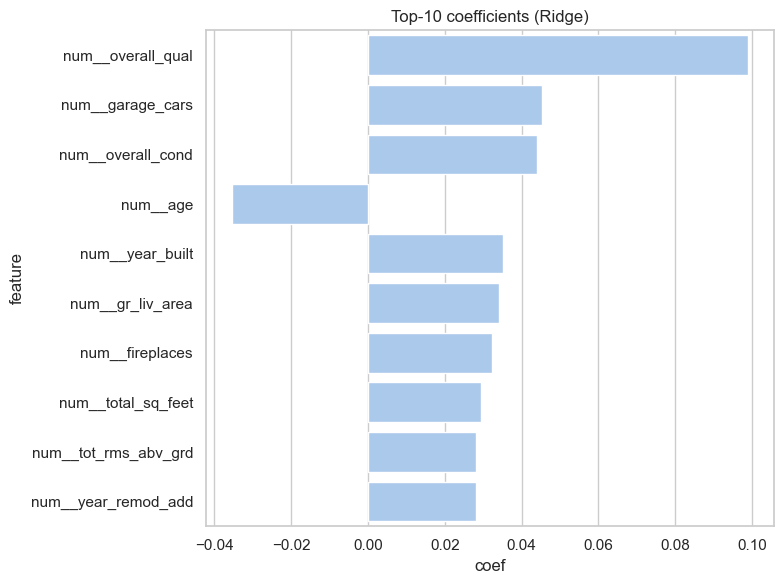

In [ ]:
pre = model_ridge.named_steps["preprocess"]
feature_names = pre.get_feature_names_out()
coefs = model_ridge.named_steps["ridge"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})

coef_df["abs_coef"] = coef_df["coef"].abs()
top_10_ridge = coef_df.sort_values("abs_coef", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_10_ridge, y="feature", x="coef")
plt.title("Top-10 coefficients (Ridge)")
plt.tight_layout()
plt.show()

## Section summary:
- Fit a Ridge regression pipeline with one-hot encoding + median imputation.
- Tuned the regularization strength via a grid of alpha values.


- Best alpha: 153.6175
- Ridge: RMSE = 0.1224, R² = 0.8992

 Ridge slightly improves generalization compared to plain OLS by stabilizing coefficients under multicollinearity.

 ***

 ## Lasso

In [ ]:
# Lasso
lasso = LassoCV(
    alphas=np.logspace(-4, 0, 60),   
    cv=5,
    random_state=42,
    max_iter=20000
)

model_lasso = Pipeline(steps=[
    ("preprocess", preprocess),
    ("lasso", lasso)
])

In [ ]:
model_lasso.fit(X_train, y_train)
y_pred = model_lasso.predict(X_test)

rmse_lasso = rmse(y_test, y_pred)
r2_lasso = r2_score(y_test, y_pred)
best_alpha = model_lasso.named_steps["lasso"].alpha_

print("LASSO")
print(f"Best alpha: {best_alpha:.4f}")
print(f"Lasso RMSE: {rmse_lasso:.4f}")
print(f"Lasso R2: {r2_lasso:.4f}")

LASSO
Best alpha: 0.0058
Lasso RMSE: 0.1255
Lasso R2: 0.8939


In [ ]:
coefs = model_lasso.named_steps["lasso"].coef_
n_nonzero = int(np.sum(coefs != 0))
n_total = coefs.shape[0]

print(f"Non-zero coefficients: {n_nonzero} / {n_total}")

Non-zero coefficients: 20 / 40


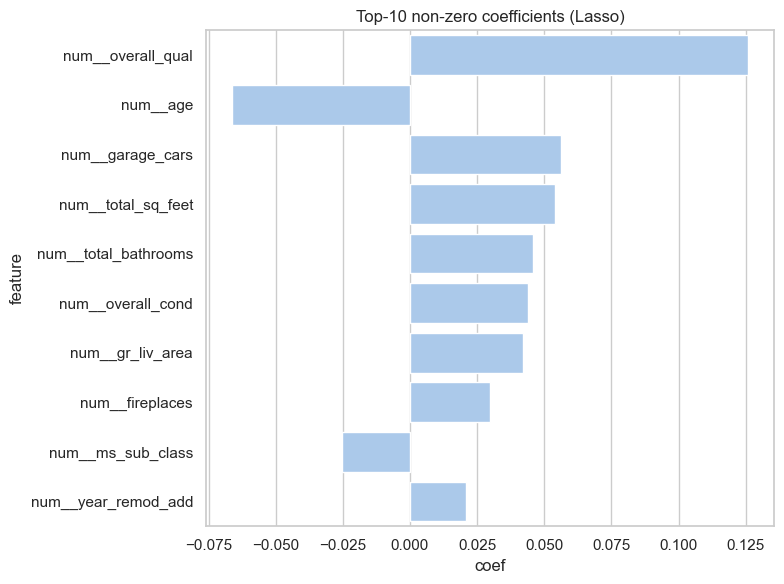

In [ ]:
pre = model_lasso.named_steps["preprocess"]
feature_names = pre.get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model_lasso.named_steps["lasso"].coef_
})

coef_df["abs_coef"] = coef_df["coef"].abs()

top_10_lasso = coef_df.query("coef != 0").sort_values("abs_coef", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_10_lasso, y="feature", x="coef")
plt.title("Top-10 non-zero coefficients (Lasso)")
plt.tight_layout()
plt.show()

## Section summary: 
- Fit a Lasso regression pipeline (same preprocessing as Ridge).
- Tuned alpha to balance sparsity and accuracy.


- Best alpha: 0.0058
- Lasso: RMSE = 0.1255, R² = 0.8939

Lasso performs variable selection (many coefficients become exactly zero), improving interpretability, but here it costs some predictive accuracy compared with Ridge/OLS.

***

## Random Forest

In [ ]:
# Fit a Random Forest regressor as a nonlinear ensemble baseline
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=2
)

model_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

rmse_rf = rmse(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST")
print(f"RF RMSE: {rmse_rf:.4f}")
print(f"RF R2: {r2_rf:.4f}")

RANDOM FOREST
RF RMSE: 0.1311
RF R2: 0.8843


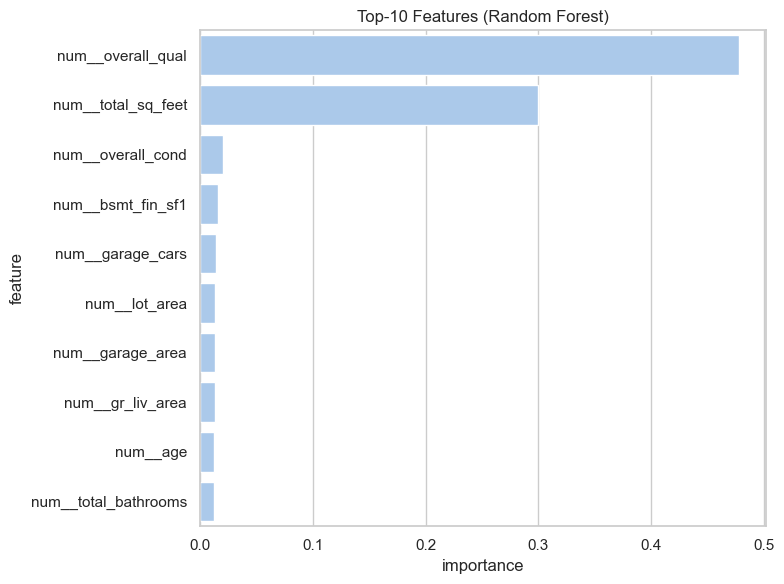

In [ ]:
pre = model_rf.named_steps["preprocess"]
rf_fitted = model_rf.named_steps["rf"]
feature_names = pre.get_feature_names_out()

imp = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_fitted.feature_importances_
}).sort_values("importance", ascending=False)

top_10_rf = imp.head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_10_rf, y="feature", x="importance")
plt.title("Top-10 Features (Random Forest)")
plt.tight_layout()
plt.show()

***
## Boosting

In [ ]:
# Fit a Gradient Boosting regressor 
gbr = GradientBoostingRegressor(
    random_state=42,
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3
)

model_gbr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("gbr", gbr)
])

model_gbr.fit(X_train, y_train)
y_pred_gbr = model_gbr.predict(X_test)

rmse_gbr = rmse(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("GRADIENT BOOSTING")
print(f"Boosting RMSE: {rmse_gbr:.4f}")
print(f"Boosting R2: {r2_gbr:.4f}")

GRADIENT BOOSTING
Boosting RMSE: 0.1169
Boosting R2: 0.9080


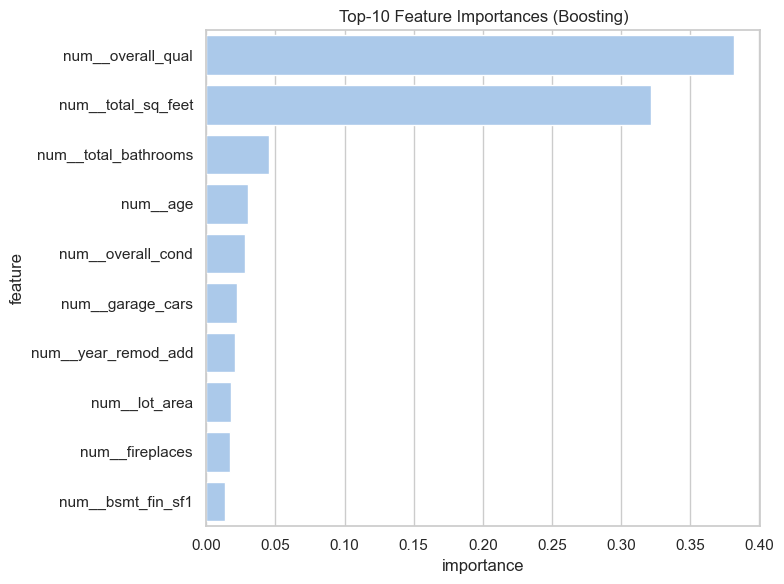

In [ ]:
gbr_fitted = model_gbr.named_steps["gbr"]
feature_names = pre.get_feature_names_out()

imp_gbr = pd.DataFrame({
    "feature": feature_names,
    "importance": gbr_fitted.feature_importances_
}).sort_values("importance", ascending=False)

top_10_gbr = imp_gbr.head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_10_gbr, y="feature", x="importance")
plt.title("Top-10 Feature Importances (Boosting)")
plt.tight_layout()
plt.show()

In [ ]:
results = pd.DataFrame([
    {"model": "Random Forest", "RMSE test": rmse_rf, "R2 test": r2_rf},
    {"model": "Gradient Boosting", "RMSE test": rmse_gbr, "R2 test": r2_gbr},
])

results.sort_values("RMSE test")

,model,RMSE test,R2 test
1,Gradient Boosting,0.116886,0.908001
0,Random Forest,0.131061,0.884333


In [ ]:
comparison = pd.DataFrame([
    {"Model": "OLS", "RMSE test": rmse_ols, "R2 test": r2_ols},
    {"Model": "Stepwise OLS (AIC)", "RMSE test": rmse_step, "R2 test": r2_step},
    {"Model": "Ridge Regression", "RMSE test": rmse_ridge, "R2 test": r2_ridge},
    {"Model": "Lasso Regression", "RMSE test": rmse_lasso, "R2 test": r2_lasso},
    {"Model": "Regression Tree", "RMSE test": rmse_tree,  "R2 test": r2_tree},
    {"Model": "Random Forest", "RMSE test": rmse_rf, "R2 test": r2_rf},
    {"Model": "Gradient Boosting", "RMSE test": rmse_gbr, "R2 test": r2_gbr},
])

comparison.sort_values("RMSE test")


,Model,RMSE test,R2 test
6,Gradient Boosting,0.116886,0.908001
2,Ridge Regression,0.122366,0.899173
0,OLS,0.122975,0.898165
1,Stepwise OLS (AIC),0.123549,0.897213
3,Lasso Regression,0.125517,0.893912
5,Random Forest,0.131061,0.884333
4,Regression Tree,0.167376,0.811354


# Final Conclusion:

- In this project, I analyzed the House Prices dataset using several regression and machine learning methods in order to predict residential property values and to study the main determinants of house prices.

- After data cleaning, exploratory data analysis, and preprocessing, multiple models were implemented and evaluated, including Ordinary Least Squares (OLS), Stepwise OLS with AIC, Ridge Regression, Lasso Regression, Regression Trees, Random Forests, and Gradient Boosting. Model performance was assessed using RMSE and `R2` on a held-out test set.

- The results show that Gradient Boosting achieved the best predictive performance, with the lowest test `RMSE (0.1169)` and the highest test `R² (0.9080)`. This indicates that Gradient Boosting is able to capture complex nonlinear relationships and interactions between variables more effectively than linear models and single decision trees.

- Among the linear models, Ridge Regression and OLS performed very well, with `RMSE` values around `0.12` and `R2` values close to `0.90`. This suggests that linear relationships explain a large portion of the variation in house prices. Regularization through Ridge Regression slightly improved stability compared to standard OLS, especially in the presence of multicollinearity. 

- Stepwise OLS using AIC produced results similar to standard OLS, indicating that automatic variable selection did not lead to substantial performance improvements in this dataset. Lasso Regression showed slightly weaker performance, likely due to excessive shrinkage of relevant predictors.

- Tree-based models showed mixed results. While Random Forest performed reasonably well, it did not outperform Gradient Boosting or linear models. The single Regression Tree exhibited the weakest performance, confirming its tendency to overfit and its limited ability to generalize.

- From an interpretability perspective, linear and regularized models remain valuable because they provide clear coefficient estimates and allow statistical inference. In contrast, Gradient Boosting offers superior predictive accuracy but at the cost of reduced interpretability.

- The analysis also revealed that house quality, living area, garage capacity, and neighborhood characteristics are among the most important factors influencing sale prices. These findings are consistent with economic intuition and real estate theory.

- Regarding uncertainty, residual and performance analysis indicated that prediction errors are larger for high-priced properties, suggesting that extreme values are more difficult to model accurately. This highlights the importance of considering uncertainty when using prediction models in practice.

**Overall**, this project demonstrates that advanced ensemble methods such as Gradient Boosting provide the highest predictive accuracy for house price estimation, while regularized linear models offer a strong balance between performance and interpretability. The results emphasize the importance of combining classical statistical methods with modern machine learning techniques in applied data analysis.